📊 Rangkuman Statistik:

|   Volume (ml) |   Mean_Time_s |   SD_Time_s |   Mean_Flow_Rate |   SD_Flow_Rate |   CV_Flow_Rate (%) |
|--------------:|--------------:|------------:|-----------------:|---------------:|-------------------:|
|            20 |        11.49  |       0.141 |            1.741 |          0.021 |              1.223 |
|            40 |        22.77  |       0.094 |            1.757 |          0.007 |              0.412 |
|            60 |        34.026 |       0.126 |            1.763 |          0.007 |              0.371 |
|            80 |        45.446 |       0.114 |            1.76  |          0.004 |              0.252 |
|           100 |        56.95  |       0.112 |            1.756 |          0.003 |              0.197 |


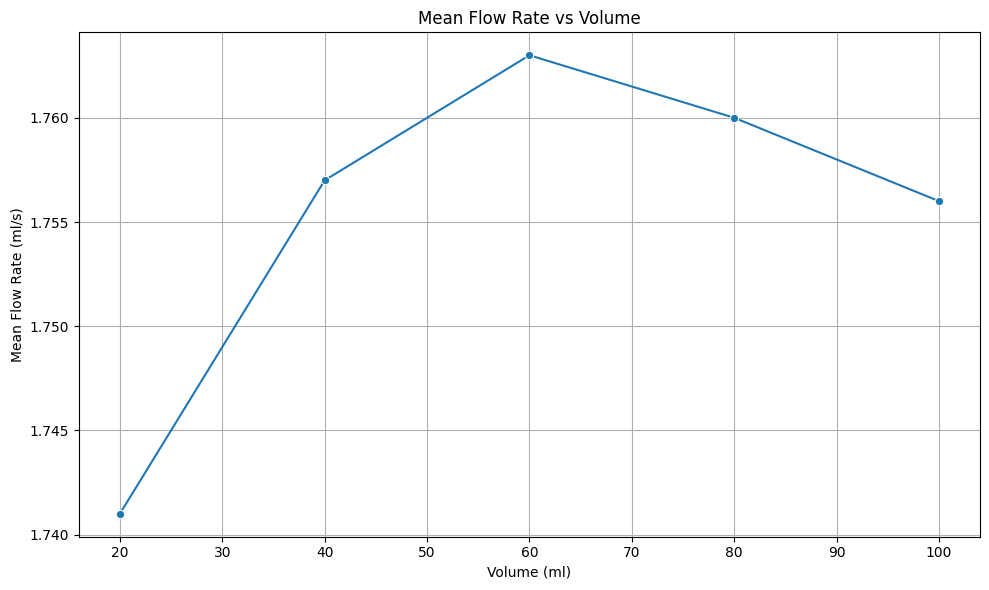

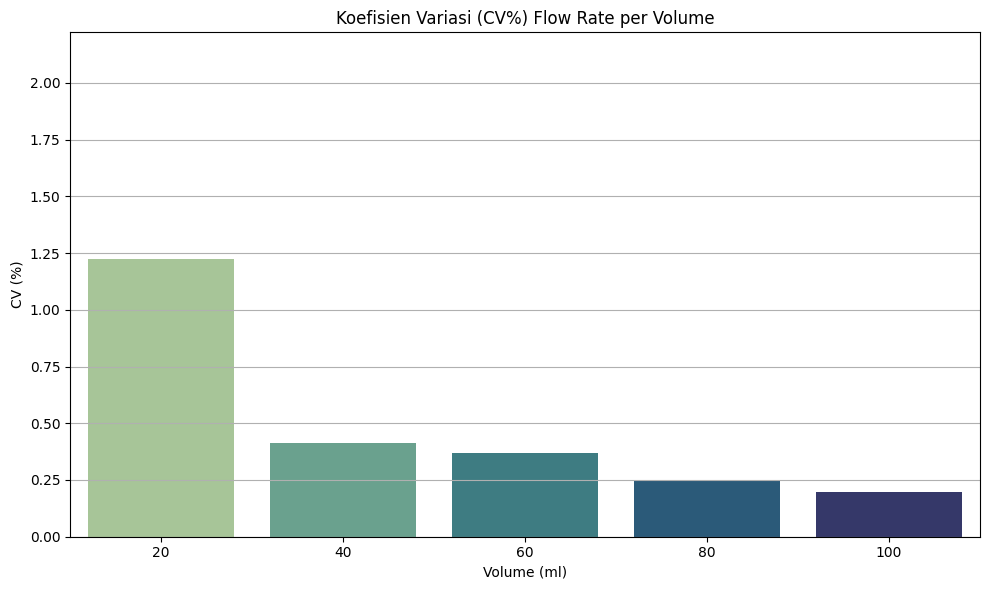

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------
# STEP 1: Masukkan data pengujian
# -------------------------------------
data = {
    20: [11.50, 11.37, 11.53, 11.70, 11.35],
    40: [22.76, 22.90, 22.71, 22.66, 22.82],
    60: [34.00, 33.95, 34.10, 33.88, 34.20],
    80: [45.30, 45.45, 45.60, 45.50, 45.38],
    100: [56.90, 56.80, 57.00, 56.95, 57.10]
}

# Buat DataFrame dari data
rows = []
for volume, times in data.items():
    for t in times:
        rows.append({
            "Volume (ml)": volume,
            "Time (s)": t,
            "Flow Rate (ml/s)": round(volume / t, 4)
        })

df = pd.DataFrame(rows)

# -------------------------------------
# STEP 2: Hitung Statistik: Mean, SD, CV
# -------------------------------------
summary = df.groupby("Volume (ml)").agg(
    Mean_Time_s=("Time (s)", "mean"),
    SD_Time_s=("Time (s)", "std"),
    Mean_Flow_Rate=("Flow Rate (ml/s)", "mean"),
    SD_Flow_Rate=("Flow Rate (ml/s)", "std"),
)
summary["CV_Flow_Rate (%)"] = (summary["SD_Flow_Rate"] / summary["Mean_Flow_Rate"]) * 100
summary = summary.round(3)
print("📊 Rangkuman Statistik:\n")
print(summary.to_markdown())

# -------------------------------------
# STEP 3: Visualisasi
# -------------------------------------

summary_plot = summary.reset_index()

# Plot 1: Flow Rate vs Volume
plt.figure(figsize=(10, 6))
sns.lineplot(data=summary_plot, x="Volume (ml)", y="Mean_Flow_Rate", marker='o')
plt.title("Mean Flow Rate vs Volume")
plt.xlabel("Volume (ml)")
plt.ylabel("Mean Flow Rate (ml/s)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: CV vs Volume
plt.figure(figsize=(10, 6))
sns.barplot(
    data=summary_plot,
    x="Volume (ml)",
    y="CV_Flow_Rate (%)",
    hue="Volume (ml)",
    palette="crest",
    legend=False
)
plt.title("Koefisien Variasi (CV%) Flow Rate per Volume")
plt.xlabel("Volume (ml)")
plt.ylabel("CV (%)")
plt.ylim(0, summary_plot["CV_Flow_Rate (%)"].max() + 1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
